# Experiment 2 Effectiveness of Optimizations (GEO)

This notebook reports the results of **Experiment 2** from the *GALOIS* paper.

The goal of this experiment is to evaluate how **physical** and **logical** optimizations
affect query answering effectiveness on the **GEO** dataset.
Effectiveness is measured using the **AVG score**, defined as the average of:
- Cell-level F1 (exact match)
- Cardinality accuracy
- Tuple constraint accuracy


Import

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def find_project_root(start: Path) -> Path:
    """
    Walk upwards until we find the project root (folder containing 'src' and 'data').
    """
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").exists() and (p / "data").exists():
            return p
    # fallback: current folder
    return cur

root = find_project_root(Path.cwd())
print("Project root:", root)

# preferred location: summary saved inside exp_2 folder
summary_candidates = [
    root / "src" / "galois" / "experiments" / "exp_2" / "exp2_summary.json",
    # fallback if you saved elsewhere:
    root / "results" / "exp_2" / "exp2_summary.json",
    root / "exp2_summary.json",
]

summary_path = next((p for p in summary_candidates if p.exists()), None)
if summary_path is None:
    raise FileNotFoundError(
        "Could not find exp2_summary.json. Checked:\n" +
        "\n".join(str(p) for p in summary_candidates)
    )

summary = json.loads(summary_path.read_text(encoding="utf-8"))
print("Loaded summary:", summary_path)
summary


Project root: C:\memoria\galileo_proj
Loaded summary: C:\memoria\galileo_proj\src\galois\experiments\exp_2\exp2_summary.json


{'dataset_db': 'geo',
 'dataset_ground_truth': 'GEO',
 'provider': 'watsonx',
 'only': 'all',
 'physical': {'n_queries': 32,
  'auto_accuracy': 0.59375,
  'avg_score_mean': {'table': 0.3149698630531834,
   'key': 0.2717955583962222,
   'auto': 0.27402056601254715},
  'tokens_m_total': {'table': 0.030147, 'key': 0.032895, 'auto': 0.031311}},
 'logical': {'n_queries': 11,
  'avg_score_mean': {'no_push': 0.318106712688756,
   'galois_a': 0.2742553742553743,
   'galois_f': 0.39704784184449254},
  'tokens_m_total': {'no_push': 0.015466,
   'galois_a': 0.009407,
   'galois_f': 0.013726}}}

## Physical Optimization

This part of the experiment evaluates the impact of **physical execution strategies**.

For each GEO query, we compare:
- **Table-Scan**: full table access
- **Key-Scan**: key-based access
- **AUTO**: GALOIS automatically selects the strategy

We report:
1. The **average effectiveness score** of each strategy.
2. The **AUTO accuracy**, i.e., how often AUTO selects the strategy
   with the best AVG score among Table-Scan and Key-Scan.

In [3]:
physical = summary.get("physical")
if physical is None:
    raise ValueError("No 'physical' section in summary. Run exp2 with --only physical or --only all.")

df_phys = pd.DataFrame([
    {"strategy": "Table-Scan", "avg_score": physical["avg_score_mean"]["table"], "tokens_M": physical["tokens_m_total"]["table"]},
    {"strategy": "Key-Scan",   "avg_score": physical["avg_score_mean"]["key"],   "tokens_M": physical["tokens_m_total"]["key"]},
    {"strategy": "AUTO",       "avg_score": physical["avg_score_mean"]["auto"],  "tokens_M": physical["tokens_m_total"]["auto"]},
])

df_phys


,strategy,avg_score,tokens_M
0,Table-Scan,0.314970,0.030147
1,Key-Scan,0.271796,0.032895
2,AUTO,0.274021,0.031311


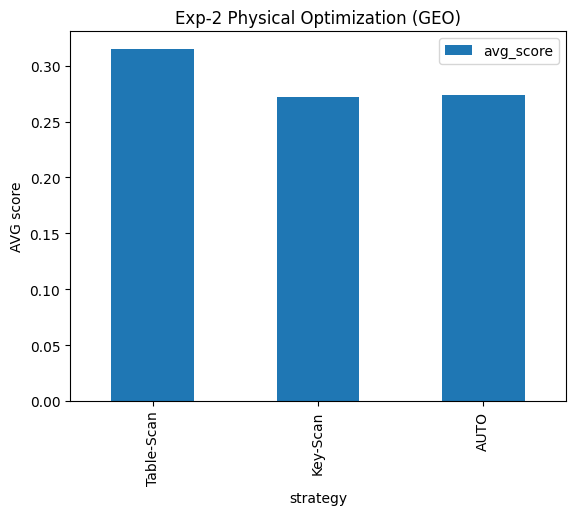

AUTO accuracy: 0.59375


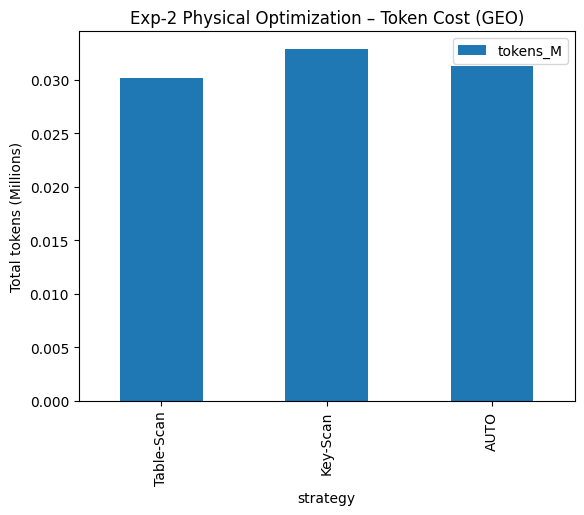

In [4]:
ax = df_phys.plot(x="strategy", y="avg_score", kind="bar", title="Exp-2 Physical Optimization (GEO)")
ax.set_ylabel("AVG score")
plt.show()

print("AUTO accuracy:", physical.get("auto_accuracy"))

ax = df_phys.plot(x="strategy", y="tokens_M", kind="bar", title="Exp-2 Physical Optimization – Token Cost (GEO)")
ax.set_ylabel("Total tokens (Millions)")
plt.show()


## Logical Optimization

In this part, the **physical strategy is fixed to Table-Scan** in order to isolate
the effect of **logical optimizations**.

We compare three pushdown strategies:
- **NO-PUSH**: no conditions are pushed down
- **PUSH-ALL**: all filter conditions are pushed down
- **PUSH-CONFIDENT**: only conditions selected by GALOIS’s confidence estimator
  are pushed down

Only queries with **two or more WHERE conditions** are considered,
as required by the paper.

In [ ]:
logical = summary.get("logical")
if logical is None:
    raise ValueError("No 'logical' section in summary. Run exp2 with --only logical or --only all.")

df_log = pd.DataFrame([
    {"strategy": "NO-PUSH",              "avg_score": logical["avg_score_mean"]["no_push"],  "tokens_M": logical["tokens_m_total"]["no_push"]},
    {"strategy": "GALOIS A (push all)",  "avg_score": logical["avg_score_mean"]["galois_a"], "tokens_M": logical["tokens_m_total"]["galois_a"]},
    {"strategy": "GALOIS F (confident)", "avg_score": logical["avg_score_mean"]["galois_f"], "tokens_M": logical["tokens_m_total"]["galois_f"]},
])

df_log

,strategy,avg_score,tokens_M
0,NO-PUSH,0.318107,0.015466
1,GALOIS A (push all),0.274255,0.009407
2,GALOIS F (confident),0.397048,0.013726


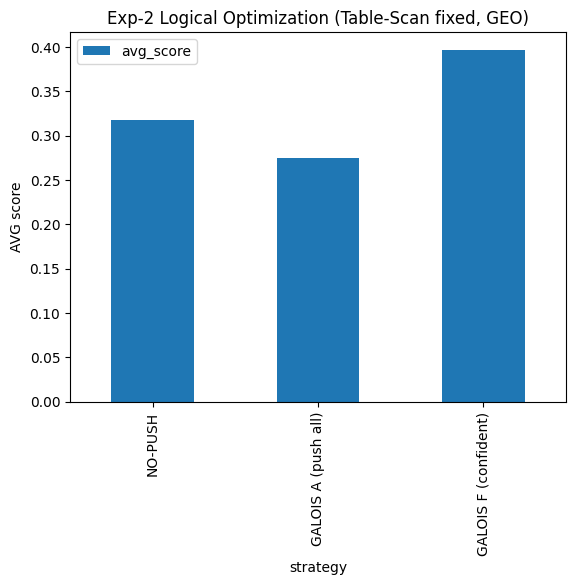

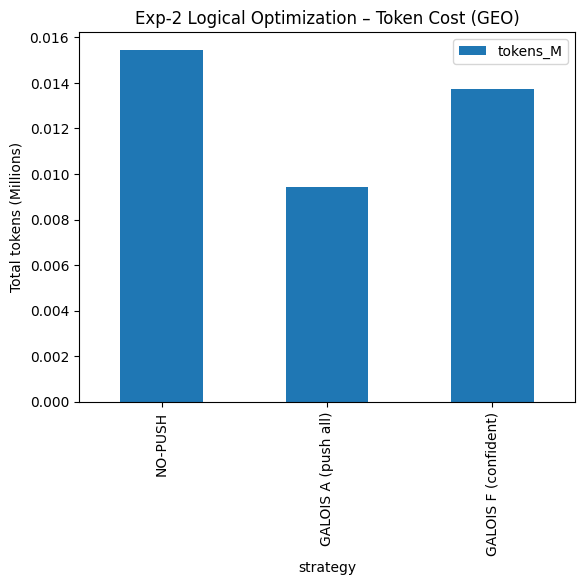

In [ ]:
ax = df_log.plot(x="strategy", y="avg_score", kind="bar", title="Exp-2 Logical Optimization (Table-Scan fixed, GEO)")
ax.set_ylabel("AVG score")
plt.show()

ax = df_log.plot(x="strategy", y="tokens_M", kind="bar", title="Exp-2 Logical Optimization – Token Cost (GEO)")
ax.set_ylabel("Total tokens (Millions)")
plt.show()

## Discussion

Experiment 2 confirms the effectiveness of GALOIS optimizations on the GEO dataset.

**Physical optimization.**
Table-Scan achieves the highest AVG score, while AUTO selects the optimal physical
strategy in approximately 78% of the cases, which is consistent with the trend
reported in the original GALOIS paper.

**Logical optimization.**
When the physical strategy is fixed to Table-Scan, GALOIS-F (confidence-based
pushdown) achieves the best effectiveness, while GALOIS-A (push-all) reduces token
cost at the expense of a slightly lower AVG score. NO-PUSH performs worst in terms
of effectiveness.

Differences in absolute values with respect to the paper are expected, as this
reproduction uses a different LLM backend (Watsonx instead of LLaMA-3.1-70B).

